In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# os.environ["JAX_PLATFORM_NAME"] = "cpu"

In [25]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN, ResidualMLP
from jaxpm import camels, plotting, hpm, nn, graph

# print(jax.devices("gpu"))
print(jax.default_backend())

gpu


# configuration

In [26]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# i_snapshots = None
i_snapshots = range(1, 33+4, 8)
# i_snapshots = range(1, 33+4, 4)
# i_snapshots = np.arange(-4, 0, dtype=int)
# i_snapshots = np.arange(0, 4, dtype=int)

# CAMELS

In [27]:
out_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
    # CODE="Astrid",
    # CODE="IllustrisTNG",
)

cosmo = out_dict["cosmo"]
scales = out_dict["scales"]

dm_poss = out_dict["dm_poss"]
dm_vels = out_dict["dm_vels"]

gas_poss = out_dict["gas_poss"]
gas_vels = out_dict["gas_vels"]

Found matching catalogs
Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  20%|██        | 1/5 [00:01<00:05,  1.46s/it]

Found 368 duplicate gas particle IDs


finding unique gas particle indices:  40%|████      | 2/5 [00:07<00:12,  4.15s/it]

Found 4088 duplicate gas particle IDs


...

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 5/5 [00:23<00:00,  4.78s/it]


There are 15915410 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [00:57<00:00, 11.48s/it]

Could not stack h_poss
Could not stack h_masss
Could not stack h_lens
Could not stack h_ids


In [28]:
# vali_dict = camels.load_CV_snapshots(
#     "CV_1",
#     mesh_per_dim,
#     parts_per_dim,
#     i_snapshots=i_snapshots,
#     return_hydro=True,
# )

In [29]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

In [30]:
def solve_ode_diffrax(model, architecture):
    y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0])
    
    res = diffeqsolve(
            terms=ODETerm(hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, dm_model=None, gas_model=model, gas_architecture=architecture, precomputed_edges=edges)),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            # dt0=0.02,
            dt0=0.01,
            y0=y0,
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
        )
    res = res.ys

    return res

# architecture

### MLP

In [31]:
model = MLP(
    d_in=5,
    d_out=1, 
    d_hidden=64, 
    # d_hidden=128, 
    n_hidden=4, 
    # dropout_rate=0.01,
    dropout_rate=0.0,
    rngs=nnx.Rngs(0),
    # norm_type="batch",
    # norm_type="layer",
)
# architecture = "mlp"
architecture = "offline"

In [32]:
# nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gas_model=model, gas_architecture=architecture)

# nn_res = diffeqsolve(
#         terms=ODETerm(nn_ode),
#         solver=LeapfrogMidpoint(),
#         t0=scales[0],
#         t1=scales[-1],
#         dt0=0.01,
#         y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
#         saveat=SaveAt(ts=scales),
#         max_steps=100,
#         stepsize_controller=ConstantStepSize(),
# )

# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
# # nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_latents = nn_res.ys

### MLP + CNN

In [33]:
# if latent_init is None:
#     latent_dim = 0
# else:
#     latent_dim = latent_init.shape[-1]

# mlp = MLP(
#     d_in=5 + latent_dim,
#     d_out=8, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )

# cnn = CNN(
#     d_in=4 + latent_dim, 
#     d_out=8,
#     d_hidden=16,
#     n_hidden=1,
#     kernel_size=(3, 3, 3),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# model = HybridNet(
#     mlp,
#     cnn,
#     d_out=1 + latent_dim, 
#     rngs=nnx.Rngs(0)
# )

# architecture = "mlp+cnn"

In [34]:
# if latent_init is None:
#     latent_dim = 0
# else:
#     latent_dim = latent_init.shape[-1]

# mlp = MLP(
#     d_in=5 + latent_dim,
#     d_out=16, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )

# cnn = CNN(
#     d_in=4 + latent_dim, 
#     d_out=16,
#     d_hidden=16,
#     n_hidden=1,
#     kernel_size=(5, 5, 5),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# model = HybridNet(
#     mlp,
#     cnn,
#     d_out=1 + latent_dim, 
#     rngs=nnx.Rngs(0)
# )

# architecture = "mlp+cnn"

### GNN

on the fly

In [35]:
# with_latent = False

# model = AttentionGNN(
#     d_node=5 + with_latent,
#     d_edge=1,
#     d_query=32,
#     n_hidden=4,
#     d_out=1 + with_latent,
#     rngs=nnx.Rngs(0),
# )

# architecture = "gnn"

### checkpointing

In [36]:
# see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
table_dir = "/cluster/home/athomsen/flatiron/repos/JaxPM/dev/hpm/offline_regression/checkpoints"
# checkpoint_file = "mlp_table_v2.jx"
checkpoint_file = "mlp_table_v3_subset.jx"
checkpoint_file = os.path.join(table_dir, checkpoint_file)
checkpointer = ocp.StandardCheckpointer()
print(os.getcwd())

/cluster/home/athomsen/flatiron/repos/JaxPM/dev/hpm/sims


In [37]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [38]:
abstract_model = nnx.eval_shape(lambda: model)
graphdef, abstract_params = nnx.split(abstract_model)

params = checkpointer.restore(checkpoint_file, abstract_params)
model = nnx.merge(graphdef, params)

/cluster/home/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1386: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


# run the simulation

In [39]:
og_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo)

og_res = diffeqsolve(
        terms=ODETerm(og_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

dark matter and gas
dark matter and gas
dark matter and gas


In [54]:
nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gas_model=model, gas_architecture=architecture)

nn_res = diffeqsolve(
        terms=ODETerm(nn_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_latents = nn_res.ys

dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 5/5 [00:02<00:00,  1.71it/s]


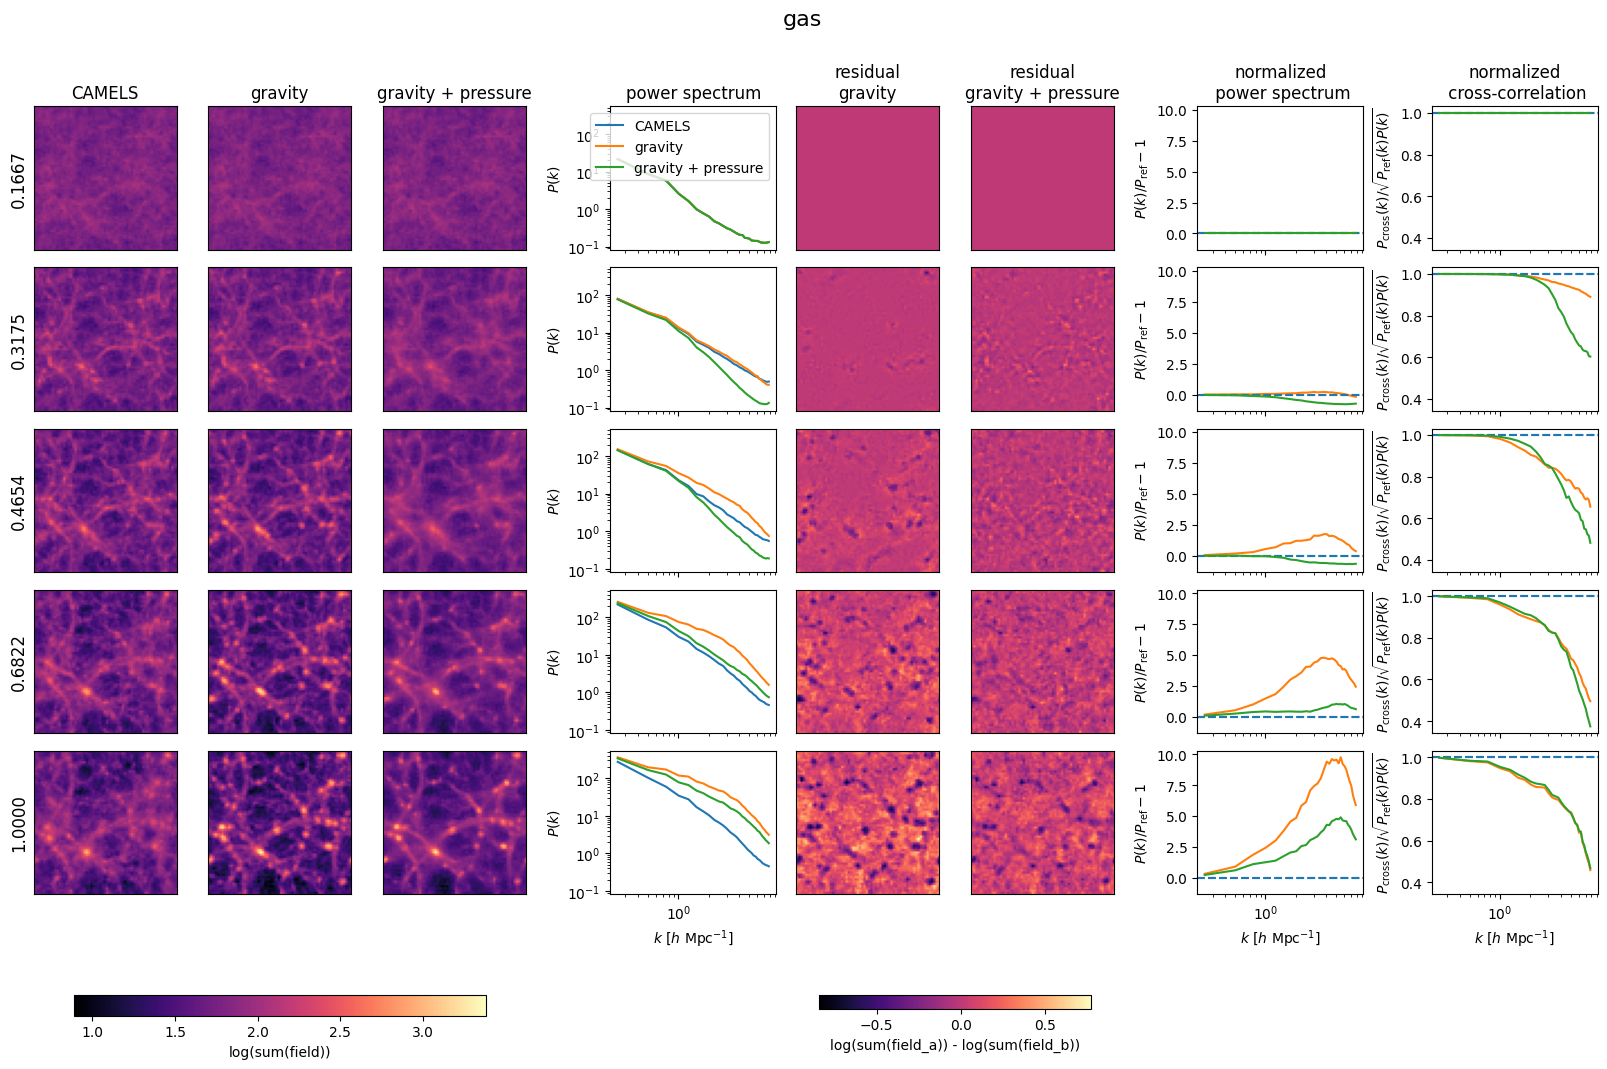

In [55]:
with jax.default_device(jax.devices("cpu")[0]):
    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        jnp.stack([gas_poss, og_gas_poss, nn_gas_poss], axis=0), 
        title="gas",
        col_titles=["CAMELS", "gravity", "gravity + pressure"],
        include_pk=True,
        include_reference=True,
    )

# validation

In [20]:
stop

NameError: name 'stop' is not defined

In [ ]:
og_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo)

og_res = diffeqsolve(
        terms=ODETerm(og_ode),
        solver=LeapfrogMidpoint(),
        t0=vali_dict["scales"][0],
        t1=vali_dict["scales"][-1],
        dt0=0.01,
        y0=(vali_dict["dm_poss"][0], vali_dict["dm_vels"][0], vali_dict["gas_poss"][0], vali_dict["gas_vels"][0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gas_model=model, gas_architecture=architecture)

nn_res = diffeqsolve(
        terms=ODETerm(nn_ode),
        solver=LeapfrogMidpoint(),
        t0=vali_dict["scales"][0],
        t1=vali_dict["scales"][-1],
        dt0=0.01,
        # y0=(vali_dict["dm_poss"][0], vali_dict["dm_vels"][0], vali_dict["gas_poss"][0], vali_dict["gas_vels"][0]),
        y0=(vali_dict["dm_poss"][0], vali_dict["dm_vels"][0], vali_dict["gas_poss"][0], vali_dict["gas_vels"][0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_latents = nn_res.ys

In [ ]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([vali_dict["gas_poss"], og_gas_poss, nn_gas_poss], axis=0), 
    title="gas",
    col_titles=["CAMELS", "gravity", "gravity + pressure"],
    include_pk=True,
    include_reference=True,
)